# 02 — Theory and Fit

We walk thru the theory ladder (linear -> one-loop SPT -> EFT), and fit the counterterm at z = 0.5, scan $k_{\rm max}$, and save the plots.

In [1]:
import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path('/n/home03/hbrittain/COSMO')
sys.path.insert(0, str(ROOT / 'src'))

from fit.fit_eft import fit_counterterm, load_measurement_artifact, load_theory_artifact, run_kmax_scan, select_k_stability
from theory.header_cosmo import cosmo_from_header
from theory.linear_baseline import make_linear_pk
from theory.spt_one_loop import compute_one_loop

### Parameters

- <span style="color:pink">*z_choice*</span> (float): target redshift snapshot
- <span style="color:pink">*nr*</span> (int): radial integration points for the SPT loop integrals (log-spaced in $q/k$)
- <span style="color:pink">*nx*</span> (int): Gauss-Legendre angular quadrature points
- <span style="color:pink">*fit_kmax*</span> (float): upper wavenumber limit for the counterterm fit
- <span style="color:pink">*scan_kmax*</span> (list): $k_{\rm max}$ values to sweep in the stability scan

In [2]:
z_choice  = 0.5
nr        = 256
nx        = 64
fit_kmax  = 0.20
scan_kmax = [0.10, 0.12, 0.14, 0.16, 0.18, 0.20]

measurement_csv  = ROOT / 'artifacts' / 'measurements' / f'matter_pk_real_z{z_choice:.3f}.csv'
measurement_meta = ROOT / 'artifacts' / 'measurements' / f'matter_pk_real_z{z_choice:.3f}.metadata.json'
header_path      = ROOT / 'data' / f'z{z_choice:.3f}' / 'AB' / 'header'
theory_dir       = ROOT / 'artifacts' / 'theory' / f'z{z_choice:.3f}'
fit_dir          = ROOT / 'artifacts' / 'fit'    / f'z{z_choice:.3f}'
theory_dir.mkdir(parents=True, exist_ok=True)
fit_dir.mkdir(parents=True, exist_ok=True)

measurement = load_measurement_artifact(measurement_csv, measurement_meta)
cosmo       = cosmo_from_header(header_path)

print(f"z = {cosmo['redshift']}   D(z) = {cosmo['D_z']:.4f}   f = {cosmo['f_growth']:.4f}")

z = 0.5   D(z) = 0.6066   f = 0.7591


### Linear Baseline

$P_{11}(k, z)$ is built from the CLASS power spectrum stored in the official Abacus metadata (fetched via `abacusutils`). CLASS was run at $z_{\rm pk} = 1$; we scale to the target epoch using the Abacus growth table:

$$P_{11}(k, z) = P_{\rm CLASS}(k,\, z_{\rm pk}) \times \left[\frac{D(z)}{D(z_{\rm pk})}\right]^2$$

The result is log-log interpolated onto a dense $k$ grid that covers the measurement range.

In [3]:
k_lin  = np.geomspace(2 * np.pi / cosmo['box_size'] * 0.5, 1.0, 300)
pk_lin = make_linear_pk(k_lin, cosmo)

linear_csv = theory_dir / f'pk_linear_z{z_choice:.3f}.csv'
np.savetxt(
    linear_csv,
    np.column_stack([k_lin, pk_lin]),
    delimiter=',', header='k_h_per_Mpc,P_lin_Mpc3_per_h3', comments='',
)
linear_csv.with_suffix('.metadata.json').write_text(
    json.dumps({'redshift': z_choice, 'source_header': str(header_path)}, indent=2)
)
linear_csv

PosixPath('/n/home03/hbrittain/COSMO/artifacts/theory/z0.500/pk_linear_z0.500.csv')

### One-Loop SPT

We need two loop corrections beyond the linear spectrum:

$$P_{22}(k) = 2\int\frac{d^3q}{(2\pi)^3}\, F_2^2(\mathbf{q},\mathbf{k}-\mathbf{q})\, P_{11}(q)\, P_{11}(|\mathbf{k}-\mathbf{q}|)$$

$$P_{13}(k) = 6\, P_{11}(k)\int\frac{d^3q}{(2\pi)^3}\, F_3(\mathbf{k}, \mathbf{q}, -\mathbf{q})\, P_{11}(q)$$

Both are computed by a 2D numerical integration: `nr` log-spaced radial points in $r = q/k$ and `nx` Gauss-Legendre angular points. The one-loop spectrum is $P_{1\rm loop} = P_{11} + P_{22} + P_{13}$.

This cell takes a few minutes with `nr=256, nx=64`.

In [4]:
theory = compute_one_loop(measurement['k_h_per_Mpc'], k_lin, pk_lin, nr=nr, nx=nx)

theory_csv = theory_dir / 'pk_spt_one_loop_for_fit.csv'
np.savetxt(
    theory_csv,
    np.column_stack([theory['k'], theory['P11'], theory['P22'], theory['P13'], theory['P_1loop']]),
    delimiter=',', header='k_h_per_Mpc,P11,P22,P13,P_1loop', comments='',
)
theory_meta = theory_csv.with_suffix('.metadata.json')
theory_meta.write_text(json.dumps({
    'artifact_role': 'spt_one_loop',
    'observable_type': 'matter_pk_real',
    'redshift': z_choice,
    'source_header': str(header_path),
    'linear_engine': 'abacus_metadata_CLASS',
    'integration_settings': {'nr': nr, 'nx': nx, 'r_min': 1e-4, 'r_max': 200.0},
}, indent=2))

theory_loaded = load_theory_artifact(theory_csv, theory_meta)
theory_csv

PosixPath('/n/home03/hbrittain/COSMO/artifacts/theory/z0.500/pk_spt_one_loop_for_fit.csv')

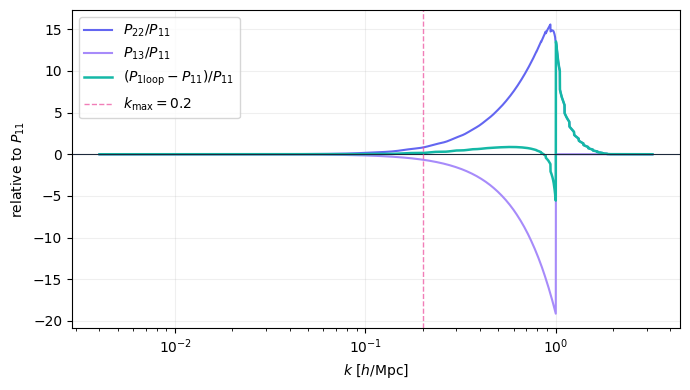

In [5]:
# quick sanity check — loop terms relative to P11
k = theory['k']
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(k, theory['P22'] / theory['P11'], color='#6366f1', label=r'$P_{22}/P_{11}$')
ax.semilogx(k, theory['P13'] / theory['P11'], color='#a78bfa', label=r'$P_{13}/P_{11}$')
ax.semilogx(k, theory['P_1loop'] / theory['P11'] - 1, color='#14b8a6', label=r'$(P_{1\rm loop} - P_{11})/P_{11}$', linewidth=1.8)
ax.axhline(0, color='#1e293b', linewidth=0.8)
ax.axvline(fit_kmax, color='#ec4899', linestyle='--', linewidth=1, alpha=0.7, label=f'$k_{{\\rm max}}={fit_kmax}$')
ax.set_xlabel(r'$k\ [h/{\rm Mpc}]$')
ax.set_ylabel('relative to $P_{11}$')
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

### EFT Counterterm Fit

The EFT corrects the loop prediction with a single-parameter counterterm:

$$P_{\rm EFT}(k) = P_{1\rm loop}(k) - 2\,c\,k^2\,P_{11}(k)$$

Positive $c$ suppresses power — physically, it encodes the UV sensitivity of the loop integrals via a single effective sound speed. Because $c$ enters linearly, the minimum of $\chi^2$ is a closed-form expression (see `fit_eft.py::fit_counterterm`). The uncertainty is $\sigma_c = 1/\sqrt{\mathcal{F}}$ where $\mathcal{F} = \sum_k (-2k^2 P_{11})^2/\sigma^2(k)$ is the Fisher information. Covariance is mode-counting: $\sigma^2(k) = 2P(k)^2/N_{\rm modes}(k)$.

In [ ]:
def to_plain(value):
    if isinstance(value, dict):       return {k: to_plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)): return [to_plain(v) for v in value]
    if isinstance(value, np.ndarray): return value.tolist()
    if isinstance(value, np.integer): return int(value)
    if isinstance(value, np.floating): return float(value)
    if isinstance(value, Path):       return str(value)
    return value

def save_columns(path, columns):
    path.parent.mkdir(parents=True, exist_ok=True)
    names = list(columns)
    with path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(names)
        for row in zip(*(columns[n] for n in names)):
            writer.writerow(row)

fit = fit_counterterm(measurement, theory_loaded, k_max_h_per_Mpc=fit_kmax)

summary = {k: v for k, v in fit.items() if k not in {'fit_columns', 'residual_columns'}}
(fit_dir / 'eft_fit_summary.json').write_text(json.dumps(to_plain(summary), indent=2))
save_columns(fit_dir / 'eft_fit_curve.csv',     fit['fit_columns'])
save_columns(fit_dir / 'eft_fit_residuals.csv', fit['residual_columns'])

print(f"c = {fit['c_counterterm_Mpch2']:.4f} +- {fit['sigma_c_counterterm_Mpch2']:.4f}  (Mpc/h)^2")
print(f"chi2/dof = {fit['chi2_dof']:.3f}   ({fit['n_points']} points, {fit['dof']} dof)")

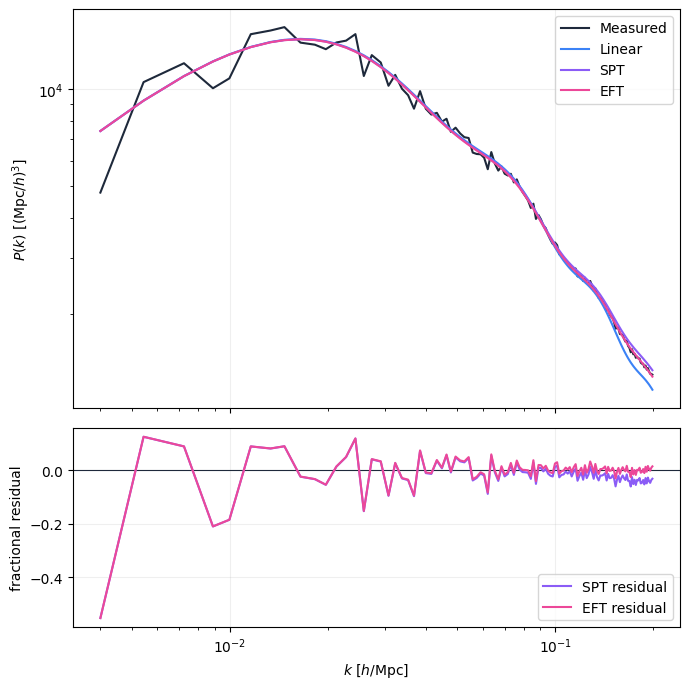

In [7]:
cols = fit['fit_columns']
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax1.loglog(cols['k_h_per_Mpc'], cols['P_meas'],   color='#1e293b', label='Measured')
ax1.loglog(cols['k_h_per_Mpc'], cols['P11'],      color='#3b82f6', label='Linear')
ax1.loglog(cols['k_h_per_Mpc'], cols['P_1loop'],  color='#8b5cf6', label='SPT')
ax1.loglog(cols['k_h_per_Mpc'], cols['P_eft'],    color='#ec4899', label='EFT')
ax1.set_ylabel(r'$P(k)\ [({\rm Mpc}/h)^3]$')
ax1.legend()
ax1.grid(alpha=0.2)

ax2.axhline(0, color='#1e293b', linewidth=0.8)
ax2.semilogx(cols['k_h_per_Mpc'], (cols['P_meas'] - cols['P11'])      / cols['P_meas'], color='#3b82f6', label='Linear residual')
ax2.semilogx(cols['k_h_per_Mpc'], (cols['P_meas'] - cols['P_1loop']) / cols['P_meas'], color='#8b5cf6', label='SPT residual')
ax2.semilogx(cols['k_h_per_Mpc'], (cols['P_meas'] - cols['P_eft'])   / cols['P_meas'], color='#ec4899', label='EFT residual')
ax2.set_xlabel(r'$k\ [h/{\rm Mpc}]$')
ax2.set_ylabel('fractional residual')
ax2.legend()
ax2.grid(alpha=0.2)

fig.tight_layout()
fig.savefig(fit_dir / 'comparison_fit.png', dpi=160)
plt.show()

### k_max Stability Scan

We expect the counterterm to be stable, so a fitted value of $c$ should not depend very strongly on how much data we include. We scan `scan_kmax` values, tracking:

- **parameter drift** $\Delta c / \sigma_c(k_{\rm ref})$ — shift in $c$ relative to its uncertainty at the reference scale
- **in-sample** $\chi^2/{\rm dof}$ — fit quality
- **holdout** $\chi^2/{\rm dof}$ — $\chi^2$ evaluated just *above* the fit range $(k_{\rm max},\, k_{\rm max}+0.04]$, testing genuine predictive power

We then select $k_{\rm stab}$ as the largest $k_{\rm max}$ where all three pass conservative thresholds (see `fit_eft.py::select_k_stability`).

In [8]:
scan = run_kmax_scan(
    measurement=measurement,
    theory=theory_loaded,
    k_max_values_h_per_Mpc=scan_kmax,
)

scan_csv = fit_dir / 'kmax_scan.csv'
with scan_csv.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=list(scan['rows'][0]))
    writer.writeheader()
    writer.writerows(scan['rows'])
(fit_dir / 'kmax_scan.metadata.json').write_text(
    json.dumps(to_plain({**scan['metadata'], 'scan_csv': str(scan_csv), 'n_scan_points': len(scan['rows'])}), indent=2)
)

selection = select_k_stability(scan=scan)
(fit_dir / 'breakdown_scale_summary.json').write_text(json.dumps(to_plain(selection), indent=2))

k_stab = selection['selected_k_stab_h_per_Mpc']
print(f"k_stab = {k_stab:.2f} h/Mpc   ({selection['selection_status']})")

# append selection fields to the main fit summary
saved_summary = json.loads((fit_dir / 'eft_fit_summary.json').read_text())
saved_summary.update({
    'selected_k_stab_h_per_Mpc':    selection['selected_k_stab_h_per_Mpc'],
    'selection_status':              selection['selection_status'],
    'selected_row_passes_all_cuts':  selection['selected_row_passes_all_cuts'],
    'parameter_drift_sigma':         selection['selected_row']['parameter_drift_sigma'],
    'chi2_holdout_dof':              selection['selected_row']['chi2_holdout_dof'],
    'selection_note':                selection['selection_note'],
})
(fit_dir / 'eft_fit_summary.json').write_text(json.dumps(saved_summary, indent=2))
scan_csv

k_stab = 0.20 h/Mpc   (largest_passing_scale)


PosixPath('/n/home03/hbrittain/COSMO/artifacts/fit/z0.500/kmax_scan.csv')

<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_716804/3743334792.py:23: SyntaxWarning: invalid escape sequence '\c'
  axes[2].scatter(kmax, holdout, marker='^', color='#f472b6', s=70, label='holdout $\chi^2$')


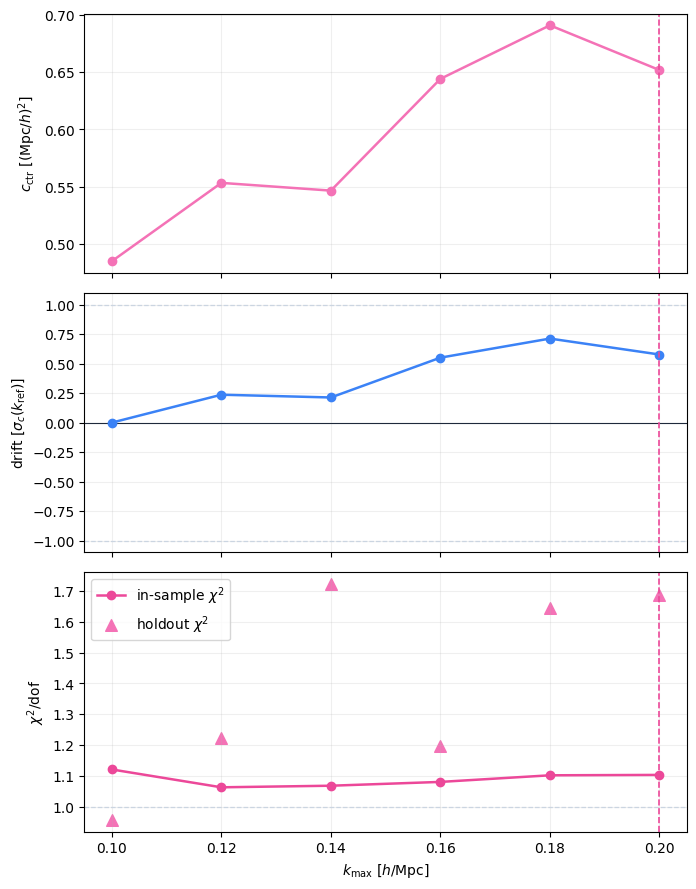

In [9]:
kmax   = np.array([r['k_max_h_per_Mpc']          for r in scan['rows']])
cvals  = np.array([r['c_counterterm_Mpch2']       for r in scan['rows']])
chi2   = np.array([r['chi2_dof']                  for r in scan['rows']])
drift  = np.array([r['parameter_drift_sigma']     for r in scan['rows']])
holdout = np.array([r['chi2_holdout_dof']         for r in scan['rows']])

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

axes[0].plot(kmax, cvals, marker='o', color='#f472b6', linewidth=1.8)
axes[0].axvline(k_stab, color='#ec4899', linestyle='--', linewidth=1.2)
axes[0].set_ylabel(r'$c_{\rm ctr}\ [({\rm Mpc}/h)^2]$')
axes[0].grid(alpha=0.2)

axes[1].axhline(0,    color='#1e293b', linewidth=0.8)
axes[1].axhline( 1.0, color='#cbd5e1', linestyle='--', linewidth=0.9)
axes[1].axhline(-1.0, color='#cbd5e1', linestyle='--', linewidth=0.9)
axes[1].plot(kmax, drift, marker='o', color='#3b82f6', linewidth=1.8)
axes[1].axvline(k_stab, color='#ec4899', linestyle='--', linewidth=1.2)
axes[1].set_ylabel(r'drift $[\sigma_c(k_{\rm ref})]$')
axes[1].grid(alpha=0.2)

axes[2].plot(kmax, chi2,    marker='o', color='#ec4899', linewidth=1.8, label=r'in-sample $\chi^2$')
axes[2].scatter(kmax, holdout, marker='^', color='#f472b6', s=70, label='holdout $\chi^2$')
axes[2].axhline(1.0, color='#cbd5e1', linestyle='--', linewidth=0.9)
axes[2].axvline(k_stab, color='#ec4899', linestyle='--', linewidth=1.2)
axes[2].set_xlabel(r'$k_{\rm max}\ [h/{\rm Mpc}]$')
axes[2].set_ylabel(r'$\chi^2/{\rm dof}$')
axes[2].legend()
axes[2].grid(alpha=0.2)

fig.tight_layout()
fig.savefig(fit_dir / 'kmax_scan.png', dpi=160)
plt.show()